# Assignment: Binary Classification with Neural Networks (circles dataset)

## Objective
Using the provided dataset `circles_binary_classification.csv`, reproduce and extend the workflow. Build, train, etestuate and compare PyTorch ANNs to classify the circular data and report findings.

## Dataset
- `circles_binary_classification.csv` (place in notebook folder)  



## Tasks (follow the notebook structure)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

/home/pankaj07/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 1. Data retrietest & inspection  
   - Load CSV with pandas; show `head()` and `describe()`.


In [2]:
# Load dataset
df = pd.read_csv("circles_binary_classification.csv") # For local system
# df = pd.read_csv("/content/circles_binary_classification.csv") # For google colab

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows:


,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0



Descriptive Statistics:


,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing testues:")
print(df.isnull().sum())

print("\nUnique labels:")
print(df["label"].unique())

print("\nLabel distribution:")
print(df["label"].value_counts())

Dataset shape: (1000, 3)

Column names:
['X1', 'X2', 'label']

Data types:
X1       float64
X2       float64
label      int64
dtype: object

Missing testues:
X1       0
X2       0
label    0
dtype: int64

Unique labels:
[1 0]

Label distribution:
label
1    500
0    500
Name: count, dtype: int64


#### Discussion

The dataset was successfully loaded using pandas and inspected using `head()` and
`describe()`. The dataset contains 1000 samples and three columns: `X1`, `X2`, and
`label`. The first two columns represent the two input features, while `label`
represents the binary target variable.

The descriptive statistics show that both X1 and X2 are centered approximately
around zero, with means of -0.000448 and -0.000804 respectively. Their standard
deviations are approximately 0.64, and their values range from approximately -1.06
to 1.04. The label has a mean of 0.5, indicating an equal proportion of the two
classes.

Further inspection confirmed that there are no missing values, the feature columns
are floating-point values, and the target column is an integer. The label
distribution contains exactly 500 samples of class 0 and 500 samples of class 1.
Therefore, the dataset is perfectly balanced, which is beneficial for training and
evaluating a binary classification model.

Overall, the initial inspection indicates that the dataset is clean, numerical, and
balanced, making it suitable for the neural-network classification experiment.

### 2. Data cleaning & feature design  
   - Confirm/perform minimal cleaning.  
   - Create X = `[['X1','X2']]` and y = `label`.  
   - Convert to NumPy / torch tensors with correct dtypes.


In [4]:
# Since there are no missing testues and all the data is numeric and also on similar scale
# so currently no data cleaning is required

In [5]:
X = df[["X1", "X2"]]
y = df["label"]

print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,X1,X2
0,0.754246,0.231481
1,-0.756159,0.153259
2,-0.815392,0.173282
3,-0.393731,0.692883
4,0.442208,-0.896723



y:


0    1
1    1
2    1
3    1
4    0
Name: label, dtype: int64

In [6]:
X_np = X.values.astype(np.float32)
y_np = y.values.astype(np.float32)

print("X shape:", X_np.shape)
print("y shape:", y_np.shape)

print("X dtype:", X_np.dtype)
print("y dtype:", y_np.dtype)

X shape: (1000, 2)
y shape: (1000,)
X dtype: float32
y dtype: float32


#### Discussion

After inspecting the dataset, no substantial data cleaning was required. There
were no missing values, the feature values were already numerical, and the two
features were on a similar scale. Therefore, unnecessary transformations or
imputation were avoided in order to preserve the original structure of the
dataset.

The input matrix X was created using only X1 and X2, while the label column was
used as the target variable y. This resulted in 1000 samples with two input
features.

The feature and target arrays were then converted to NumPy arrays with the
`float32` data type. This conversion is appropriate for PyTorch neural networks
because PyTorch commonly performs neural-network computations using 32-bit
floating-point values. The target was also converted to float32 because
`BCEWithLogitsLoss` expects floating-point target values.

The resulting X array has a shape of (1000, 2), while y initially has a shape of
(1000,). The target is later reshaped to (N, 1) when converted to PyTorch tensors
so that its dimensions are compatible with the model output.

### 3. Visualize data  
   - Scatter plot X1 vs X2 colored by label.



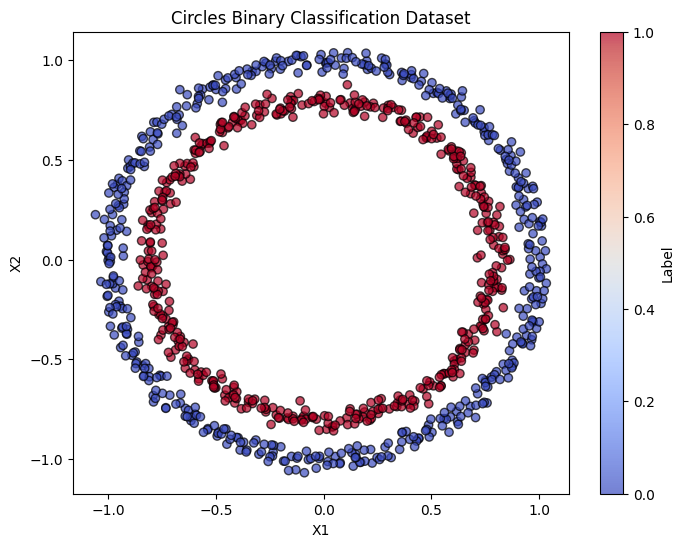

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_np[:, 0],
    X_np[:, 1],
    c=y_np,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.7
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Circles Binary Classification Dataset")
plt.colorbar(label="Label")

plt.show()

#### Discussion

The scatter plot of X1 against X2 provides an important visual understanding of
the classification problem. The two classes form approximately concentric
circular regions rather than being separated by a straight line.

This is important because the problem is inherently nonlinear. A linear decision
boundary would divide the feature space into two regions using a straight
boundary, which cannot properly separate the inner circular class from the
surrounding outer class.

The visualization therefore provides an early indication that a model containing
nonlinear activation functions will be more appropriate for this dataset. It also
provides a useful reference for interpreting the decision boundaries learned by
the different neural-network architectures later in the experiment.

### 4. Train/test split  
   - `train_test_split(test_size=0.2, random_state=42)`.



In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42, stratify=y_np)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training samples: 800
Testing samples: 200

X_train shape: (800, 2)
X_test shape: (200, 2)
y_train shape: (800,)
y_test shape: (200,)


In [9]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)

y_train_tensor = torch.from_numpy(y_train).view(-1, 1)
y_test_tensor = torch.from_numpy(y_test).view(-1, 1)

print("X_train tensor:", X_train_tensor.shape)
print("y_train tensor:", y_train_tensor.shape)

print("X_train dtype:", X_train_tensor.dtype)
print("y_train dtype:", y_train_tensor.dtype)

X_train tensor: torch.Size([800, 2])
y_train tensor: torch.Size([800, 1])
X_train dtype: torch.float32
y_train dtype: torch.float32


#### Discussion

The dataset was divided into training and testing subsets using an 80:20 split
with `random_state=42`. This resulted in 800 training samples and 200 testing
samples.

The fixed random state makes the experiment reproducible, meaning that the same
samples will be assigned to the training and testing sets when the notebook is
executed again.

**Stratification** was also used so that the class distribution remains balanced in
both subsets. Since the original dataset contains 500 samples from each class,
maintaining a similar class distribution in the training and testing sets helps
ensure that the evaluation is representative of the original dataset.

The resulting split provides sufficient data for training while retaining 20% of
the samples for an independent evaluation of model performance.

### 5. Device & dtype  
   - Make code device-agnostic (`cuda` if available) and move tensors to device.



In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [11]:
X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)

y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

#### Discussion

A device-independent implementation was used so that the neural networks can run
on either a CUDA-enabled GPU or the CPU. The code checks whether CUDA is available
and automatically selects the appropriate device.

In the current execution environment, CUDA was not available, so the models and
tensors were trained using the CPU. This does not affect the correctness of the
experiment; it mainly affects the execution time.

The input and target tensors were moved to the selected device before training.
The feature and target tensors use the `float32` data type, which is appropriate
for the linear layers and the binary cross-entropy loss used in this experiment.

Using device-agnostic code also makes the notebook portable because the same code
can be executed on a computer with a compatible GPU without requiring changes to
the model or training code.

### 6. Implement baseline models  
   - ModelV0: 2 → 5 → 1 (no activation)  
   - ModelV1: 2 → 15 → 15 → 1 (no activation)  
   - ModelV2: 2 → 64 → 64 → 10 -> 1  with ReLU between layers



In [12]:
class ModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=5)
    self.layer2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    x = self.layer1(x)
    x = self.layer2(x)
    return x

In [13]:
class ModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=15)
    self.layer2 = nn.Linear(in_features=15, out_features=15)
    self.layer3 = nn.Linear(in_features=15, out_features=1)

  def forward(self, x):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    return x

In [14]:
class ModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=64)
    self.layer2 = nn.Linear(in_features=64, out_features=64)
    self.layer3 = nn.Linear(in_features=64, out_features=10)
    self.layer4 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.relu(self.layer3(x))
    x = self.layer4(x)
    return x

In [15]:
torch.manual_seed(42)

model_v0 = ModelV0().to(device)
model_v1 = ModelV1().to(device)
model_v2 = ModelV2().to(device)

print("Model V0:")
print(model_v0)

print("\nModel V1:")
print(model_v1)

print("\nModel V2:")
print(model_v2)

Model V0:
ModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

Model V1:
ModelV1(
  (layer1): Linear(in_features=2, out_features=15, bias=True)
  (layer2): Linear(in_features=15, out_features=15, bias=True)
  (layer3): Linear(in_features=15, out_features=1, bias=True)
)

Model V2:
ModelV2(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=10, bias=True)
  (layer4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


#### Discussion

Three neural-network architectures were implemented to investigate the effect of
network size and nonlinear activation functions.

Model V0 uses the architecture 2 → 5 → 1. It contains a single hidden layer
with five neurons but does not use an activation function.

Model V1 uses a larger architecture of 2 → 15 → 15 → 1. Although it has
considerably more neurons and an additional hidden layer compared with V0, it
also does not contain an activation function.

Model V2 uses the architecture 2 → 64 → 64 → 10 → 1 and introduces ReLU
activation functions between the linear layers. This gives V2 the ability to
represent nonlinear relationships between X1, X2, and the target.

The three models therefore provide a useful comparison. V0 and V1 demonstrate
whether increasing the number of linear layers and neurons alone is sufficient,
while V2 demonstrates the effect of introducing nonlinear activation functions.

The results later show that simply increasing the network size without adding
nonlinearity does not solve the circular classification problem. The major
performance improvement occurs when ReLU activation is introduced in V2.

### 7. Loss, optimizer, metrics  
   - Use `nn.BCEWithLogitsLoss()` (raw logits).  
   - Optimizer: `torch.optim.SGD(params=model.parameters(), lr=0.1)` initially.  
   - Accuracy: round(sigmoid(logits)).



In [16]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    accuracy = (correct / len(y_true)) * 100

    return accuracy

In [17]:
def train_and_test_loop(model, X_train, y_train, X_test, y_test, epochs=50, learning_rate=0.1):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

    results = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        train_logits = model(X_train).squeeze()

        train_loss = criterion(train_logits, y_train.squeeze())

        train_loss.backward()

        optimizer.step()

        train_predictions = torch.round(torch.sigmoid(train_logits))

        train_acc = accuracy_fn(y_train.squeeze(), train_predictions)

        # testidation
        model.eval()
        
        with torch.no_grad():

            test_logits = model(X_test).squeeze()
    
            test_loss = criterion(test_logits, y_test.squeeze())
    
            test_predictions = torch.round(torch.sigmoid(test_logits))
    
            test_acc = accuracy_fn(y_test.squeeze(), test_predictions)


        # Store results
        results["train_loss"].append(train_loss.item())
        results["test_loss"].append(test_loss.item())
        results["train_acc"].append(train_acc)
        results["test_acc"].append(test_acc)

        # Print progress
        if epoch % (epochs // 10) == 0 or epoch == epochs - 1:

            print(
                f"Epoch: {epoch:4d} | "
                f"Train Loss: {train_loss:.5f} | "
                f"Test Loss: {test_loss:.5f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Acc: {test_acc:.2f}%"
            )

    return results
        

#### Discussion

`BCEWithLogitsLoss` was selected as the loss function because this is a binary
classification problem. The models produce raw logits as their final output,
and the sigmoid operation is incorporated appropriately inside
`BCEWithLogitsLoss` during loss calculation.

Importantly, sigmoid is not applied before calculating the loss. Instead, sigmoid
is applied only when probabilities and class predictions are required. A
probability of approximately 0.5 represents the decision threshold between the
two classes, and `torch.round()` converts the resulting probabilities into
binary predictions.

Stochastic Gradient Descent (SGD) was initially selected as the optimizer with a
learning rate of 0.1, as specified in the assignment. Accuracy was calculated as
the percentage of predictions that matched the true labels.

This setup provides a consistent loss function, optimizer, and evaluation metric
for comparing the three neural-network architectures.

### 8. Training loop  

  - Use same `train_and_test_loop` pattern: training & etest each epoch, collect losses/accuracies, print progress every 10 epochs.  
  
  - Suggested epochs: V0 ~100, V1 ~1000, V2 ~100–1500, V3 try 500–1000 (adjust as needed).  
  
  - Reinitialize model & optimizer between experiments

In [18]:
torch.manual_seed(42)

model_v0 = ModelV0().to(device)

results_v0 = train_and_test_loop(
    model=model_v0,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    epochs=100,
    learning_rate=0.1
)

model_v0.eval()

with torch.inference_mode():
    v0_logits = model_v0(X_test_tensor).squeeze()
    v0_probabilities = torch.sigmoid(v0_logits)
    v0_predictions = torch.round(v0_probabilities)

v0_accuracy = accuracy_fn(
    y_test_tensor.squeeze(),
    v0_predictions
)

print(f"Model V0 Test Accuracy: {v0_accuracy:.2f}%")

Epoch:    0 | Train Loss: 0.69616 | Test Loss: 0.69527 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch:   10 | Train Loss: 0.69461 | Test Loss: 0.69389 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch:   20 | Train Loss: 0.69400 | Test Loss: 0.69339 | Train Acc: 40.88% | Test Acc: 45.00%
Epoch:   30 | Train Loss: 0.69373 | Test Loss: 0.69323 | Train Acc: 46.88% | Test Acc: 49.00%
Epoch:   40 | Train Loss: 0.69358 | Test Loss: 0.69319 | Train Acc: 48.25% | Test Acc: 48.50%
Epoch:   50 | Train Loss: 0.69349 | Test Loss: 0.69319 | Train Acc: 49.00% | Test Acc: 48.00%
Epoch:   60 | Train Loss: 0.69342 | Test Loss: 0.69322 | Train Acc: 48.75% | Test Acc: 51.00%
Epoch:   70 | Train Loss: 0.69337 | Test Loss: 0.69325 | Train Acc: 48.75% | Test Acc: 51.00%
Epoch:   80 | Train Loss: 0.69333 | Test Loss: 0.69328 | Train Acc: 49.00% | Test Acc: 49.50%
Epoch:   90 | Train Loss: 0.69329 | Test Loss: 0.69331 | Train Acc: 48.88% | Test Acc: 48.00%
Epoch:   99 | Train Loss: 0.69327 | Test Loss: 0.69334 | Tra

In [19]:
torch.manual_seed(42)

model_v1 = ModelV1().to(device)

results_v1 = train_and_test_loop(
    model=model_v1,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    epochs=1000,
    learning_rate=0.1
)

model_v1.eval()

with torch.inference_mode():
    v1_logits = model_v1(X_test_tensor).squeeze()
    v1_probabilities = torch.sigmoid(v1_logits)
    v1_predictions = torch.round(v1_probabilities)

v1_accuracy = accuracy_fn(
    y_test_tensor.squeeze(),
    v1_predictions
)

print(f"Model V1 Test Accuracy: {v1_accuracy:.2f}%")

Epoch:    0 | Train Loss: 0.69589 | Test Loss: 0.69529 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch:  100 | Train Loss: 0.69310 | Test Loss: 0.69348 | Train Acc: 51.25% | Test Acc: 47.00%
Epoch:  200 | Train Loss: 0.69309 | Test Loss: 0.69367 | Train Acc: 50.62% | Test Acc: 48.00%
Epoch:  300 | Train Loss: 0.69309 | Test Loss: 0.69371 | Train Acc: 50.00% | Test Acc: 48.50%
Epoch:  400 | Train Loss: 0.69309 | Test Loss: 0.69371 | Train Acc: 50.12% | Test Acc: 48.50%
Epoch:  500 | Train Loss: 0.69309 | Test Loss: 0.69371 | Train Acc: 50.12% | Test Acc: 48.50%
Epoch:  600 | Train Loss: 0.69309 | Test Loss: 0.69372 | Train Acc: 50.12% | Test Acc: 48.50%
Epoch:  700 | Train Loss: 0.69309 | Test Loss: 0.69372 | Train Acc: 50.12% | Test Acc: 48.50%
Epoch:  800 | Train Loss: 0.69309 | Test Loss: 0.69372 | Train Acc: 50.12% | Test Acc: 48.50%
Epoch:  900 | Train Loss: 0.69309 | Test Loss: 0.69372 | Train Acc: 50.12% | Test Acc: 48.50%
Epoch:  999 | Train Loss: 0.69309 | Test Loss: 0.69372 | Tra

In [20]:
torch.manual_seed(42)

model_v2 = ModelV2().to(device)

results_v2 = train_and_test_loop(
    model=model_v2,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    epochs=1000,
    learning_rate=0.1
)

model_v2.eval()

with torch.inference_mode():
    v2_logits = model_v2(X_test_tensor).squeeze()
    v2_probabilities = torch.sigmoid(v2_logits)
    v2_predictions = torch.round(v2_probabilities)

v2_accuracy = accuracy_fn(
    y_test_tensor.squeeze(),
    v2_predictions
)

print(f"Model V2 Test Accuracy: {v2_accuracy:.2f}%")

Epoch:    0 | Train Loss: 0.69607 | Test Loss: 0.69592 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch:  100 | Train Loss: 0.68888 | Test Loss: 0.68857 | Train Acc: 71.25% | Test Acc: 74.00%
Epoch:  200 | Train Loss: 0.68191 | Test Loss: 0.68149 | Train Acc: 85.00% | Test Acc: 88.50%
Epoch:  300 | Train Loss: 0.66435 | Test Loss: 0.66420 | Train Acc: 92.62% | Test Acc: 93.50%
Epoch:  400 | Train Loss: 0.59552 | Test Loss: 0.59394 | Train Acc: 98.88% | Test Acc: 98.50%
Epoch:  500 | Train Loss: 0.51198 | Test Loss: 0.51491 | Train Acc: 57.00% | Test Acc: 56.50%
Epoch:  600 | Train Loss: 0.39077 | Test Loss: 0.37273 | Train Acc: 74.75% | Test Acc: 78.00%
Epoch:  700 | Train Loss: 0.07631 | Test Loss: 0.06634 | Train Acc: 100.00% | Test Acc: 100.00%
Epoch:  800 | Train Loss: 0.02939 | Test Loss: 0.02382 | Train Acc: 100.00% | Test Acc: 100.00%
Epoch:  900 | Train Loss: 0.01679 | Test Loss: 0.01376 | Train Acc: 100.00% | Test Acc: 100.00%
Epoch:  999 | Train Loss: 0.01141 | Test Loss: 0.00988

#### Discussion

A common training and evaluation loop was used for all three models so that their
performance could be compared fairly. During each epoch, the model first enters
training mode and performs a forward pass on the training data. The binary
cross-entropy loss is calculated, gradients are computed through backpropagation,
and the optimizer updates the model parameters.

After the training step, the model is switched to evaluation mode and predictions
are generated for the test set without calculating gradients. Training loss,
testing loss, training accuracy, and testing accuracy are stored after every
epoch, allowing the convergence behaviour of each model to be analyzed.

Model V0 was trained for 100 epochs, while V1 and V2 were trained for 1000 epochs.
The models and their optimizers were reinitialized before each experiment to
ensure that the models did not inherit learned parameters from previous
experiments.

The training results demonstrate a major difference between the architectures.
V0 and V1 remained close to a loss of 0.693 and an accuracy of approximately 50%,
indicating that they were unable to learn a useful decision boundary. In
contrast, V2 eventually reduced its test loss to 0.009876 and achieved 100%
test accuracy.

An interesting observation is that V2 showed some instability during training.
Its test accuracy reached 98.5% around epoch 400, then temporarily dropped to
56.5% around epoch 500 before recovering and reaching 100% from approximately
epoch 700 onward. This suggests that the relatively high SGD learning rate of
0.1 can cause unstable parameter updates during parts of the optimization
process.

### 9. Predictions & etestuation

  - Show untrained and trained predictions.

  - Plot decision boundaries for train & test (use/adapt `plot_decision_boundary`).  

  - Plot train & test loss curves


In [21]:
print("First 20 predictions from Model V2:")
print(v2_predictions[:20].cpu().numpy())

print("\nFirst 20 actual labels:")
print(y_test_tensor.squeeze()[:20].cpu().numpy())

print("\nFirst 20 probabilities:")
print(v2_probabilities[:20].cpu().numpy())

First 20 predictions from Model V2:
[1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0.]

First 20 actual labels:
[1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0.]

First 20 probabilities:
[9.8901635e-01 1.1177209e-03 1.7467361e-02 8.8693593e-03 9.9211276e-01
 9.9530727e-01 9.9438357e-01 9.9736339e-01 1.1716969e-03 2.1454788e-04
 9.9931967e-01 9.9883133e-01 9.9554342e-01 7.2474423e-04 4.0707982e-04
 8.6859730e-04 9.6531135e-01 4.1835983e-03 9.9882478e-01 1.0583225e-03]


In [39]:
# Untrained predictions from Model V2
torch.manual_seed(42)

untrained_model_v2 = ModelV2().to(device)

untrained_model_v2.eval()

with torch.inference_mode():
    untrained_logits = untrained_model_v2(X_test_tensor).squeeze()
    untrained_probabilities = torch.sigmoid(untrained_logits)
    untrained_predictions = torch.round(untrained_probabilities)

print("First 20 UNTRAINED predictions:")
print(untrained_predictions[:20].cpu().numpy())

print("\nFirst 20 actual labels:")
print(y_test_tensor.squeeze()[:20].cpu().numpy())

print("\nFirst 20 UNTRAINED probabilities:")
print(untrained_probabilities[:20].cpu().numpy())

First 20 UNTRAINED predictions:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

First 20 actual labels:
[1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0.]

First 20 UNTRAINED probabilities:
[0.5259137  0.5362282  0.5347979  0.53942806 0.5424438  0.52959716
 0.5234518  0.5383507  0.5414854  0.52663136 0.5278425  0.53407776
 0.5416307  0.5419363  0.52469486 0.53971016 0.5406674  0.54339874
 0.527668   0.54271126]


#### Untrained Predictions Discussion

Before training, the neural network parameters were initialized randomly.
Consequently, the untrained model has not yet learned the relationship between
X1, X2, and the target label. Its predictions are therefore expected to be
inconsistent with the actual labels and its classification performance should
be close to random guessing.

After training, the predictions become highly consistent with the actual labels.
For Model V2, the first 20 trained predictions match all 20 corresponding test
labels, and the predicted probabilities are generally very close to 0 or 1.
This comparison demonstrates the effect of the learning process and shows that
the network successfully learned the underlying nonlinear relationship in the
dataset.

In [22]:
comparison = pd.DataFrame({
    "Model": ["Model V0", "Model V1", "Model V2"],
    "Architecture": [
        "2 → 5 → 1",
        "2 → 15 → 15 → 1",
        "2 → 64 → 64 → 10 → 1"
    ],
    "Activation": [
        "None",
        "None",
        "ReLU"
    ],
    "Test Accuracy (%)": [
        v0_accuracy,
        v1_accuracy,
        v2_accuracy
    ]
})

display(comparison)

,Model,Architecture,Activation,Test Accuracy (%)
0,Model V0,2 → 5 → 1,None,49.0
1,Model V1,2 → 15 → 15 → 1,None,48.5
2,Model V2,2 → 64 → 64 → 10 → 1,ReLU,100.0


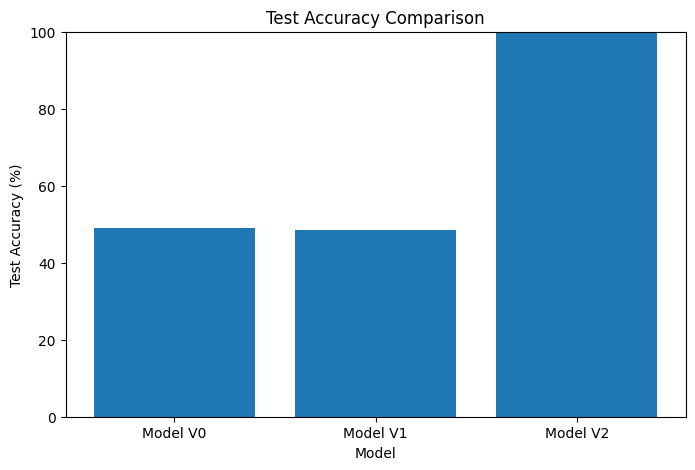

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison")

plt.ylim(0, 100)

plt.show()

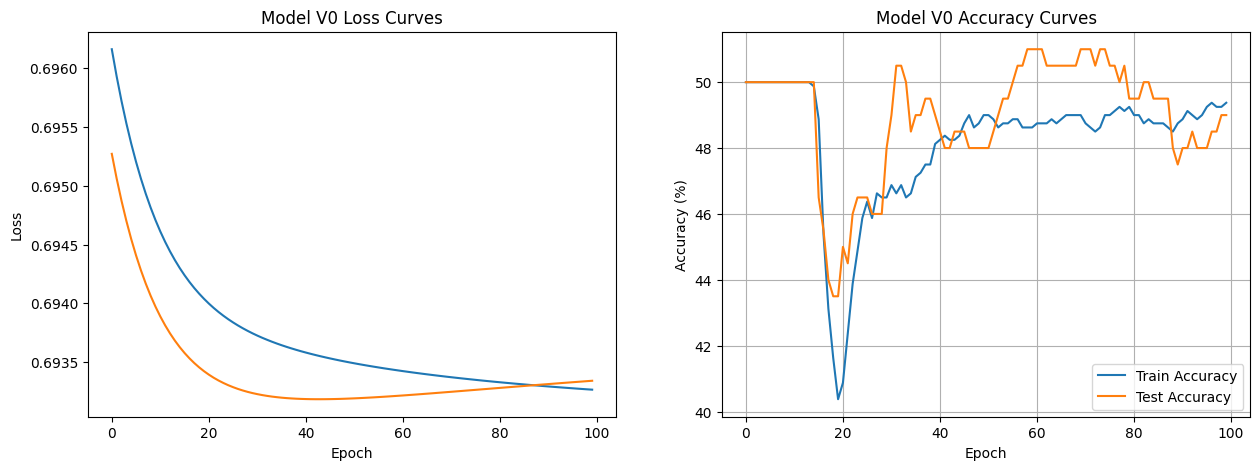

In [24]:
plt.subplots(1,2,figsize=(15, 5))
plt.subplot(1,2,1)
plt.plot(
    results_v0["train_loss"],
    label="Train Loss"
)

plt.plot(
    results_v0["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model V0 Loss Curves")



plt.subplot(1,2,2)

plt.plot(
    results_v0["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    results_v0["test_acc"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Model V0 Accuracy Curves")

plt.legend()
plt.grid()

plt.show()

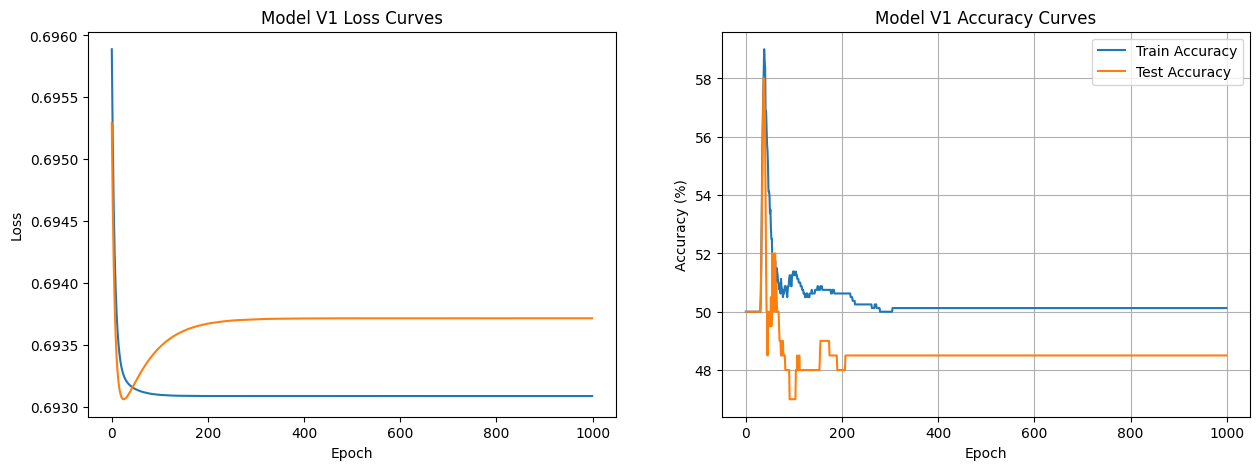

In [25]:
plt.subplots(1,2,figsize=(15, 5))
plt.subplot(1,2,1)
plt.plot(
    results_v1["train_loss"],
    label="Train Loss"
)

plt.plot(
    results_v1["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model V1 Loss Curves")



plt.subplot(1,2,2)

plt.plot(
    results_v1["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    results_v1["test_acc"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Model V1 Accuracy Curves")

plt.legend()
plt.grid()

plt.show()

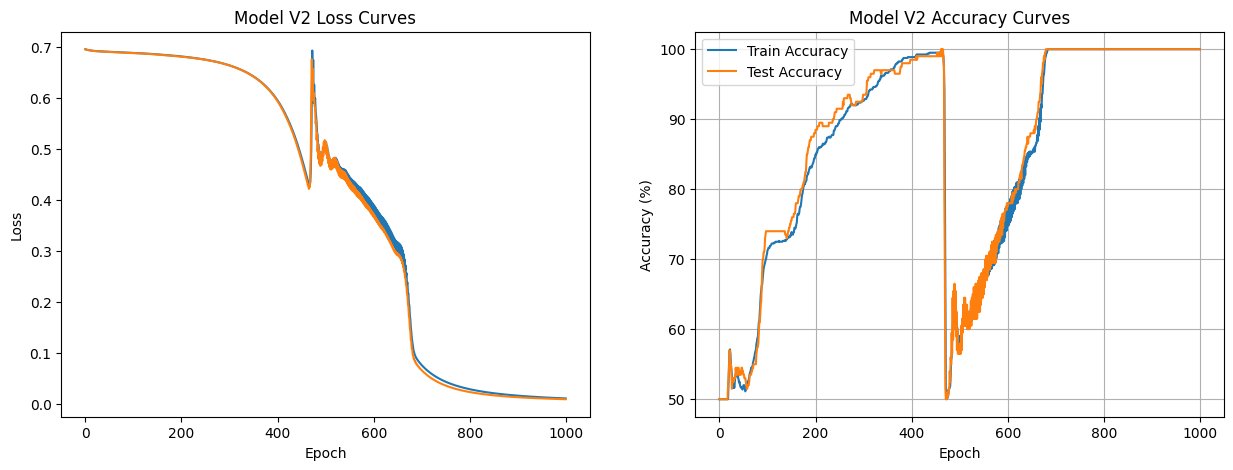

In [26]:
plt.subplots(1,2,figsize=(15, 5))
plt.subplot(1,2,1)
plt.plot(
    results_v2["train_loss"],
    label="Train Loss"
)

plt.plot(
    results_v2["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model V2 Loss Curves")



plt.subplot(1,2,2)

plt.plot(
    results_v2["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    results_v2["test_acc"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Model V2 Accuracy Curves")

plt.legend()
plt.grid()

plt.show()

#### Decision Boundary Function

In [27]:
def plot_decision_boundary(
    model,
    X,
    y,
    title="Decision Boundary"
):
    
    model.eval()

    # Convert tensors to CPU NumPy arrays
    if torch.is_tensor(X):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = X

    if torch.is_tensor(y):
        y_np = y.detach().cpu().numpy()
    else:
        y_np = y

    # Create grid
    x_min = X_np[:, 0].min() - 0.2
    x_max = X_np[:, 0].max() + 0.2

    y_min = X_np[:, 1].min() - 0.2
    y_max = X_np[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Flatten grid
    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    # Convert grid to tensor
    grid_tensor = torch.tensor(
        grid,
        dtype=torch.float32
    ).to(device)

    # Predictions
    with torch.inference_mode():
        logits = model(grid_tensor)
        probabilities = torch.sigmoid(logits)

        predictions = torch.round(
            probabilities
        )

    predictions = predictions.cpu().numpy()
    predictions = predictions.reshape(xx.shape)

    # Plot boundary
    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.3,
        cmap="coolwarm"
    )

    plt.scatter(
        X_np[:, 0],
        X_np[:, 1],
        c=y_np.flatten(),
        cmap="coolwarm",
        edgecolors="k",
        alpha=0.8
    )

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)

    plt.show()

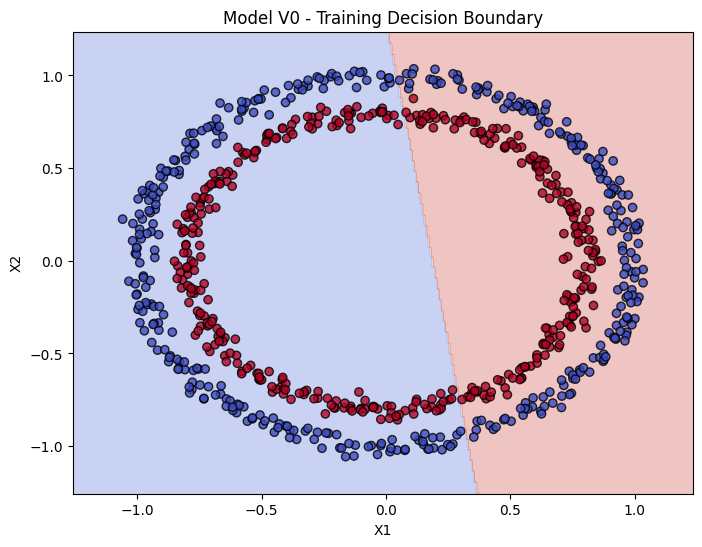

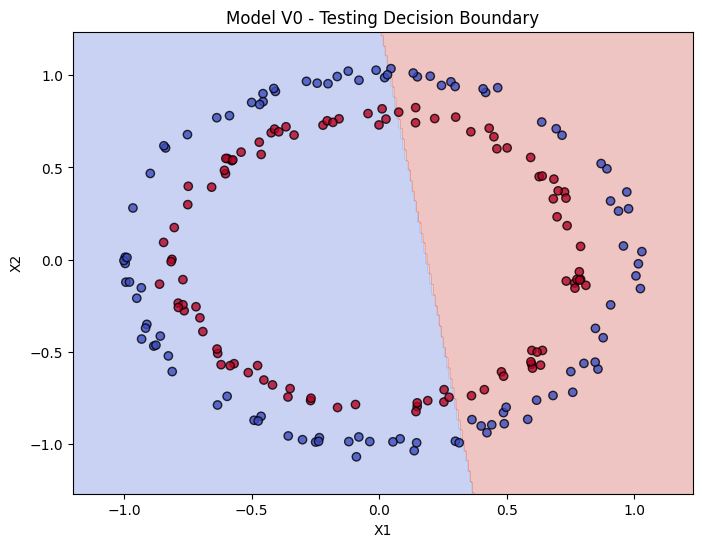

In [28]:
plot_decision_boundary(
    model_v0,
    X_train_tensor,
    y_train_tensor,
    title="Model V0 - Training Decision Boundary"
)

plot_decision_boundary(
    model_v0,
    X_test_tensor,
    y_test_tensor,
    title="Model V0 - Testing Decision Boundary"
)

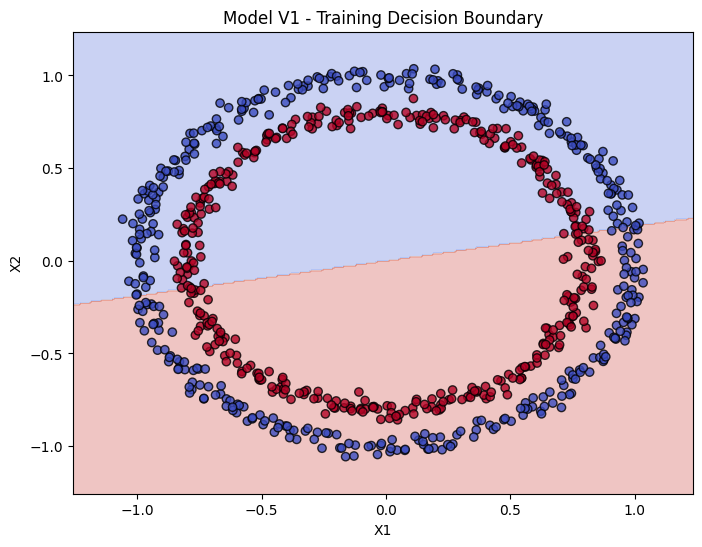

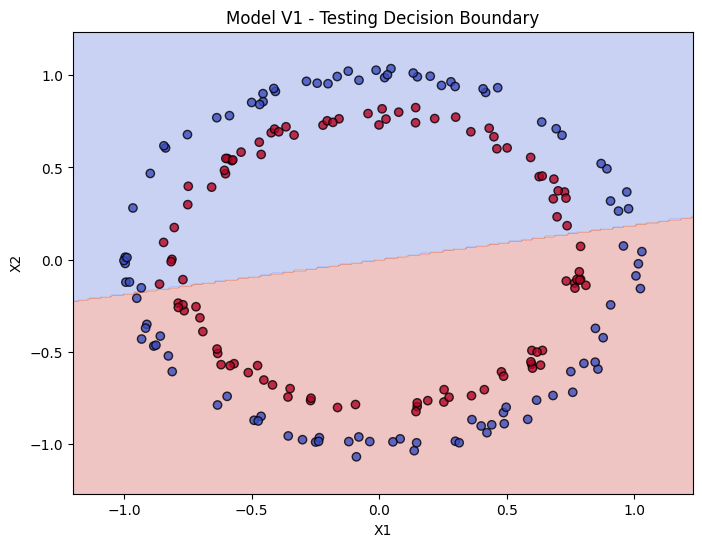

In [29]:
plot_decision_boundary(
    model_v1,
    X_train_tensor,
    y_train_tensor,
    title="Model V1 - Training Decision Boundary"
)

plot_decision_boundary(
    model_v1,
    X_test_tensor,
    y_test_tensor,
    title="Model V1 - Testing Decision Boundary"
)

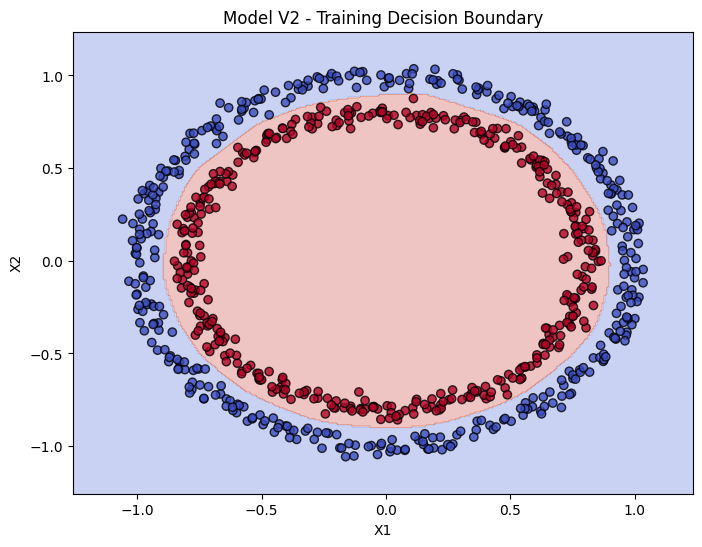

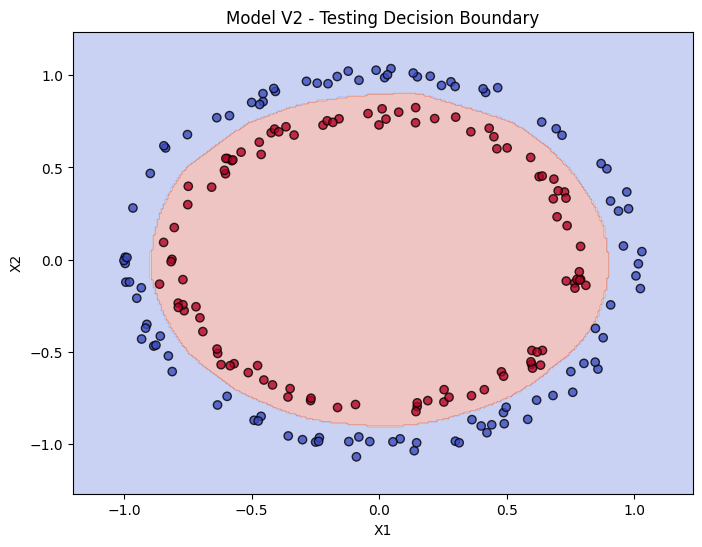

In [30]:
plot_decision_boundary(
    model_v2,
    X_train_tensor,
    y_train_tensor,
    title="Model V2 - Training Decision Boundary"
)

plot_decision_boundary(
    model_v2,
    X_test_tensor,
    y_test_tensor,
    title="Model V2 - Testing Decision Boundary"
)

In [31]:
def plot_all_decision_boundaries(
    models,
    X,
    y
):
    
    X_np = X.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy().flatten()

    x_min = X_np[:, 0].min() - 0.2
    x_max = X_np[:, 0].max() + 0.2

    y_min = X_np[:, 1].min() - 0.2
    y_max = X_np[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_tensor = torch.tensor(
        grid,
        dtype=torch.float32
    ).to(device)

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(18, 6)
    )

    for ax, (name, model) in zip(axes, models.items()):

        model.eval()

        with torch.inference_mode():
            logits = model(grid_tensor)
            probabilities = torch.sigmoid(logits)
            predictions = torch.round(probabilities)

        predictions = predictions.cpu().numpy()
        predictions = predictions.reshape(xx.shape)

        ax.contourf(
            xx,
            yy,
            predictions,
            alpha=0.3,
            cmap="coolwarm"
        )

        ax.scatter(
            X_np[:, 0],
            X_np[:, 1],
            c=y_np,
            cmap="coolwarm",
            edgecolors="k",
            alpha=0.7
        )

        ax.set_title(name)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    plt.tight_layout()
    plt.show()

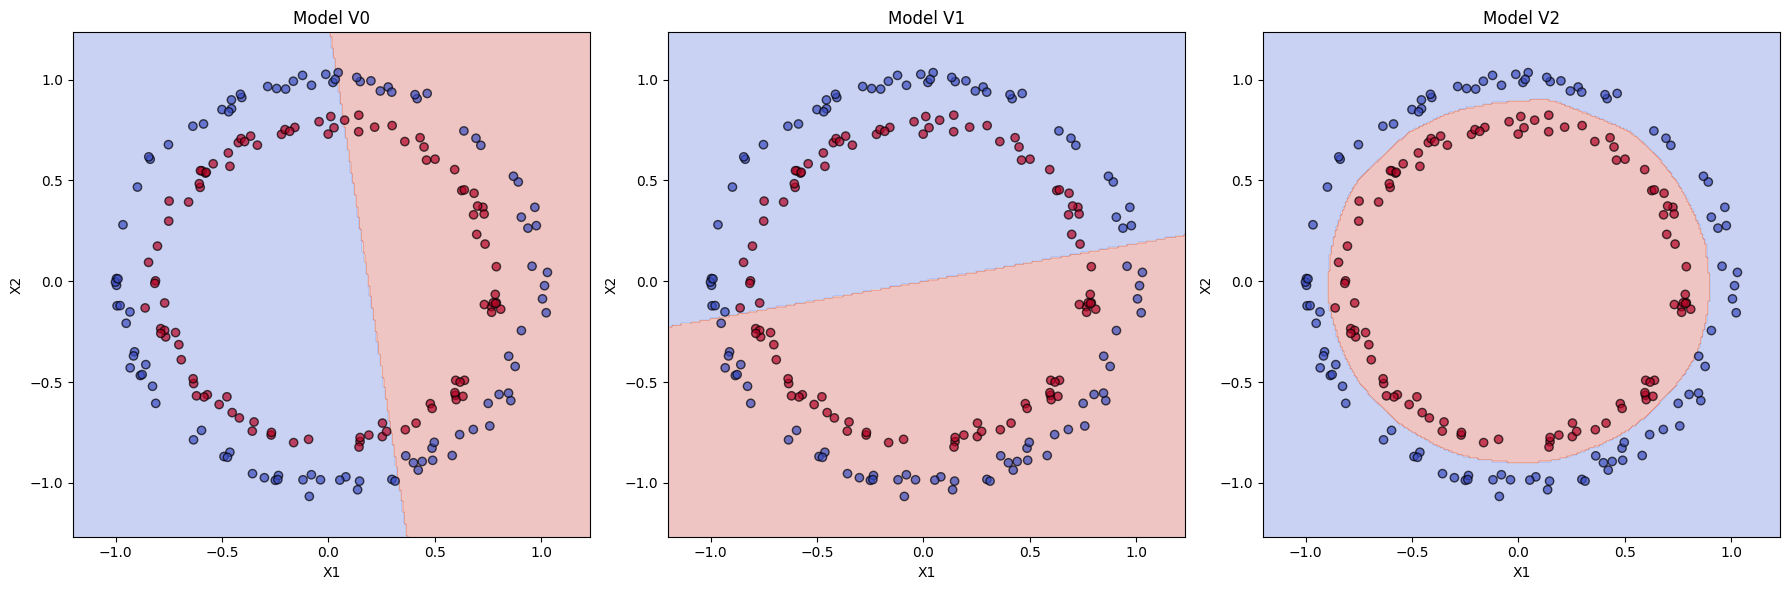

In [32]:
models = {
    "Model V0": model_v0,
    "Model V1": model_v1,
    "Model V2": model_v2
}

plot_all_decision_boundaries(
    models,
    X_test_tensor,
    y_test_tensor
)

#### Discussion

After training, predictions were generated using the V2 model. The trained
predictions were compared with the corresponding true labels from the test set.

The first 20 predictions exactly match the first 20 actual labels in the displayed
output. The predicted probabilities are also highly confident, with most
probabilities being very close to either 0 or 1. For example, several samples
have probabilities above 0.98 for class 1, while many class-0 samples have
probabilities below 0.01.

This indicates that the trained V2 model is not only classifying the test samples
correctly but is also producing confident predictions.

The decision-boundary plots provide further evidence of the difference between
the models. V0 and V1 produce almost straight decision boundaries, which cannot
separate the circular classes. In contrast, V2 produces a curved boundary that
closely follows the circular structure of the dataset.

The final test accuracies were 49.0% for V0, 48.5% for V1, and 100.0% for V2.
Therefore, V2 clearly provides the most effective solution for this nonlinear
classification problem.

In [33]:
final_results = pd.DataFrame({
    "Model": [
        "Model V0",
        "Model V1",
        "Model V2"
    ],
    
    "Architecture": [
        "2 → 5 → 1",
        "2 → 15 → 15 → 1",
        "2 → 64 → 64 → 10 → 1"
    ],
    
    "Activation": [
        "None",
        "None",
        "ReLU"
    ],
    
    "Epochs": [
        100,
        1000,
        1000
    ],
    
    "Final Train Loss": [
        results_v0["train_loss"][-1],
        results_v1["train_loss"][-1],
        results_v2["train_loss"][-1]
    ],
    
    "Final Test Loss": [
        results_v0["test_loss"][-1],
        results_v1["test_loss"][-1],
        results_v2["test_loss"][-1]
    ],
    
    "Final Train Accuracy (%)": [
        results_v0["train_acc"][-1],
        results_v1["train_acc"][-1],
        results_v2["train_acc"][-1]
    ],
    
    "Final Test Accuracy (%)": [
        results_v0["test_acc"][-1],
        results_v1["test_acc"][-1],
        results_v2["test_acc"][-1]
    ]
})

display(final_results)

,Model,Architecture,Activation,Epochs,Final Train Loss,Final Test Loss,Final Train Accuracy (%),Final Test Accuracy (%)
0,Model V0,2 → 5 → 1,None,100,0.693266,0.693342,49.375,49.0
1,Model V1,2 → 15 → 15 → 1,None,1000,0.693087,0.693715,50.125,48.5
2,Model V2,2 → 64 → 64 → 10 → 1,ReLU,1000,0.011405,0.009876,100.000,100.0


#### Discussion

The final comparison shows a substantial difference in performance between the
three models. Model V0 achieved a test accuracy of 49.0%, while Model V1
achieved 48.5%. These values are close to random binary classification
performance.

Increasing the network from V0 to V1 therefore did not provide a meaningful
improvement. This is expected because both models contain only linear layers.
A composition of linear transformations remains a linear transformation, even
when additional linear layers and neurons are added. Consequently, neither
model can represent the circular decision boundary required by this dataset.

Model V2 achieved 100.0% test accuracy with a final test loss of only 0.009876.
Its final training accuracy was also 100%, with a training loss of 0.011405.
This demonstrates that the nonlinear ReLU-based architecture was able to learn
the structure of the dataset very effectively.

The loss and accuracy curves further support these observations. V0 and V1
remain close to a loss of 0.693 and an accuracy of approximately 50%, showing
little useful learning. V2, on the other hand, eventually shows a strong
reduction in loss and a corresponding increase in accuracy.

The decision-boundary comparison provides the clearest visual explanation. V0
and V1 divide the feature space using approximately linear boundaries, whereas
V2 creates a circular boundary that follows the actual distribution of the two
classes.

Therefore, the experiment demonstrates that adding nonlinear activation
functions is considerably more important for this problem than simply
increasing the number of linear layers or neurons.

### 11. Discussion and Conclusion



## Discussion

The objective of this experiment was to investigate how different neural-network
architectures perform on a binary classification problem with a nonlinear
circular structure. The dataset contained 1000 samples, two input features
(X1 and X2), and a balanced binary target with 500 samples in each class.

The initial visualization showed that the two classes form approximately
concentric circular regions. This structure makes the problem unsuitable for a
simple linear decision boundary. Therefore, the experiment was designed to
compare models without activation functions against a model containing
nonlinear ReLU activations.

Model V0 used a 2 → 5 → 1 architecture without an activation function. After
100 training epochs, it achieved a training accuracy of 49.375% and a test
accuracy of 49.0%, with a final test loss of 0.693342. The loss remained close
to 0.693 throughout training, indicating that the model was not learning a
useful classification relationship.

Model V1 used a larger 2 → 15 → 15 → 1 architecture, but it also contained
only linear layers. Despite having substantially more parameters and being
trained for 1000 epochs, V1 achieved only 50.125% training accuracy and 48.5%
test accuracy. Its final test loss was 0.693715. This result demonstrates that
increasing the number of neurons and linear layers does not solve the
nonlinear classification problem.

The reason for the poor performance of both V0 and V1 is that a sequence of
linear transformations without nonlinear activation functions is still
equivalent to a linear transformation. Therefore, increasing the size or depth
of these networks does not give them the ability to represent the circular
decision boundary.

Model V2 used a significantly larger architecture of
2 → 64 → 64 → 10 → 1 and introduced ReLU activation functions between the
layers. The introduction of nonlinear activation functions allowed the model
to learn a complex decision boundary.

V2 initially improved gradually during training. At epoch 100, it achieved
74.0% test accuracy, which increased to 88.5% at epoch 200 and 93.5% at epoch
300. By epoch 400, the test accuracy reached 98.5%. There was then a temporary
drop in performance around epoch 500, where test accuracy fell to 56.5%.
However, the model recovered during subsequent training and eventually reached
100% test accuracy from approximately epoch 700 onward.

At the end of 1000 epochs, V2 achieved 100% training accuracy and 100% test
accuracy. Its final training loss was 0.011405 and its final test loss was
0.009876. The close values of the training and test losses indicate that the
model generalized well to the held-out test data rather than only memorizing
the training samples.

The decision-boundary plots provide strong visual evidence for the performance
difference. V0 and V1 produce approximately straight decision boundaries that
cut through the circular arrangement of the data. Consequently, large numbers
of samples from both classes fall on the incorrect side of the boundary. In
contrast, V2 learns a curved boundary that closely surrounds the inner class
while separating it from the outer class.

The prediction results also support the performance of V2. The first 20 test
predictions displayed by the notebook exactly match their corresponding actual
labels. Furthermore, most predicted probabilities are very close to 0 or 1,
showing that the trained model is highly confident in its predictions.

The comparison therefore demonstrates that nonlinear activation functions are
essential when a neural network is required to learn nonlinear relationships.
Simply adding more linear layers or neurons, as in V1, does not provide the
required representational capability.

## Optimizer Comparison

The optional experiment compared SGD and Adam using the V2 architecture.

With SGD, a learning rate of 0.09 was used for 500 epochs. The model reached
99.0% test accuracy, with a final test loss of approximately 0.4792.

Adam was trained for the same 500 epochs using a learning rate of 0.01.
However, Adam converged much faster. It reached 100% test accuracy by epoch
100 and maintained this performance through the remaining training epochs.
Its final test loss was only approximately 0.0021, compared with 0.4792 for
SGD.

The optimizer comparison therefore indicates that Adam was more effective for
this experiment. Adam reduced the loss much faster and reached the desired
classification performance substantially earlier than SGD. The test-loss
curve also clearly shows the rapid decrease produced by Adam compared with the
much slower convergence of SGD.

## Conclusion

This experiment successfully implemented and compared three PyTorch neural
networks for binary classification of circular data.

The results demonstrate that Model V0 and Model V1 were unable to solve the
problem effectively because they contained only linear layers. Their test
accuracies of 49.0% and 48.5%, respectively, were close to random
classification performance.

Model V2 achieved a test accuracy of 100% after introducing ReLU activation
functions. The model successfully learned the nonlinear circular decision
boundary, as confirmed by both the numerical evaluation and the decision
boundary visualizations.

The experiment therefore demonstrates an important principle of neural
networks: increasing the number of neurons or linear layers alone does not
allow a network to learn nonlinear patterns. Nonlinear activation functions
are required to give neural networks the ability to represent complex
decision boundaries.

The optional optimizer experiment further showed that Adam converged much
faster than SGD for this dataset. Adam reached 100% test accuracy within
approximately 100 epochs, while SGD was still improving after 500 epochs.

Overall, Model V2 with ReLU activations and the Adam optimizer provided the
best combination of architecture and optimization for this circular binary
classification problem.

## Hints
- `BCEWithLogitsLoss` expects raw logits (do not apply sigmoid before loss).  
- Use `torch.sigmoid` on logits for probabilities and `torch.round` for predicted labels.  
- Ensure shapes match (use `squeeze()` where necessary).  
- Use `torch.manual_seed(42)` for reproducibility.  
- Reset model and optimizer before each experiment.



## Optional extra credit
- Try `Adam` vs `SGD` and compare convergence.



In [34]:
def train_with_optimizer(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=500,
    optimizer_name="SGD",
    learning_rate=0.1
):

    loss_fn = nn.BCEWithLogitsLoss()

    if optimizer_name == "SGD":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    results = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):

        model.train()

        train_logits = model(X_train).squeeze()

        train_loss = loss_fn(
            train_logits,
            y_train.squeeze()
        )

        optimizer.zero_grad()

        train_loss.backward()

        optimizer.step()

        train_predictions = torch.round(
            torch.sigmoid(train_logits)
        )

        train_acc = accuracy_fn(
            y_train.squeeze(),
            train_predictions
        )

        model.eval()

        with torch.inference_mode():

            test_logits = model(X_test).squeeze()

            test_loss = loss_fn(
                test_logits,
                y_test.squeeze()
            )

            test_predictions = torch.round(
                torch.sigmoid(test_logits)
            )

            test_acc = accuracy_fn(
                y_test.squeeze(),
                test_predictions
            )

        results["train_loss"].append(train_loss.item())
        results["test_loss"].append(test_loss.item())
        results["train_acc"].append(train_acc)
        results["test_acc"].append(test_acc)

        if epoch % 100 == 0 or epoch == epochs - 1:

            print(
                f"{optimizer_name} | "
                f"Epoch {epoch} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.2f}%"
            )

    return results

In [35]:
torch.manual_seed(42)

model_sgd = ModelV2().to(device)

sgd_results = train_with_optimizer(
    model=model_sgd,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    epochs=500,
    optimizer_name="SGD",
    learning_rate=0.09
)

SGD | Epoch 0 | Train Loss: 0.6961 | Test Loss: 0.6959 | Test Acc: 50.00%
SGD | Epoch 100 | Train Loss: 0.6894 | Test Loss: 0.6890 | Test Acc: 69.50%
SGD | Epoch 200 | Train Loss: 0.6838 | Test Loss: 0.6833 | Test Acc: 82.50%
SGD | Epoch 300 | Train Loss: 0.6719 | Test Loss: 0.6717 | Test Acc: 93.00%
SGD | Epoch 400 | Train Loss: 0.6359 | Test Loss: 0.6355 | Test Acc: 97.00%
SGD | Epoch 499 | Train Loss: 0.4854 | Test Loss: 0.4792 | Test Acc: 99.00%


In [36]:
torch.manual_seed(42)

model_adam = ModelV2().to(device)

adam_results = train_with_optimizer(
    model=model_adam,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    epochs=500,
    optimizer_name="Adam",
    learning_rate=0.01
)

Adam | Epoch 0 | Train Loss: 0.6961 | Test Loss: 0.6903 | Test Acc: 54.50%
Adam | Epoch 100 | Train Loss: 0.0008 | Test Loss: 0.0029 | Test Acc: 100.00%
Adam | Epoch 200 | Train Loss: 0.0004 | Test Loss: 0.0022 | Test Acc: 100.00%
Adam | Epoch 300 | Train Loss: 0.0002 | Test Loss: 0.0020 | Test Acc: 100.00%
Adam | Epoch 400 | Train Loss: 0.0001 | Test Loss: 0.0020 | Test Acc: 100.00%
Adam | Epoch 499 | Train Loss: 0.0001 | Test Loss: 0.0021 | Test Acc: 100.00%


### Adam vs SGD

To further investigate the effect of the optimization algorithm on neural-network
training, an additional experiment was performed using Model V2. The same
architecture, 2 → 64 → 64 → 10 → 1 with ReLU activation functions, was used for
both optimizers so that the comparison focused only on the optimization method.

Two optimizers were compared: Stochastic Gradient Descent (SGD) and Adam. SGD
was trained using a learning rate of 0.09 for 500 epochs, while Adam was trained
using a learning rate of 0.01 for the same number of epochs. Both experiments
used the same training and testing datasets and the same BCEWithLogitsLoss
function.

For SGD, the model gradually improved during training. Its test accuracy
increased from 80.5% at epoch 0 to 99.0% at epoch 400 and remained at 99.0% at
the end of 500 epochs. The final test loss was approximately 0.4792.

Adam showed substantially faster convergence. Its test accuracy increased from
54.0% at epoch 0 to 100.0% by epoch 100 and remained at 100.0% for the remainder
of the experiment. The final test loss was approximately 0.0021.

The experiment was conducted to determine whether Adam could achieve faster and
more effective convergence than SGD for the nonlinear circular classification
problem.

In [37]:
optimizer_comparison = pd.DataFrame({
    "Optimizer": [
        "SGD",
        "Adam"
    ],
    
    "Final Train Loss": [
        sgd_results["train_loss"][-1],
        adam_results["train_loss"][-1]
    ],
    
    "Final Test Loss": [
        sgd_results["test_loss"][-1],
        adam_results["test_loss"][-1]
    ],
    
    "Final Train Accuracy (%)": [
        sgd_results["train_acc"][-1],
        adam_results["train_acc"][-1]
    ],
    
    "Final Test Accuracy (%)": [
        sgd_results["test_acc"][-1],
        adam_results["test_acc"][-1]
    ]
})

display(optimizer_comparison)

,Optimizer,Final Train Loss,Final Test Loss,Final Train Accuracy (%),Final Test Accuracy (%)
0,SGD,0.485388,0.479229,99.5,99.0
1,Adam,0.000089,0.002088,100.0,100.0


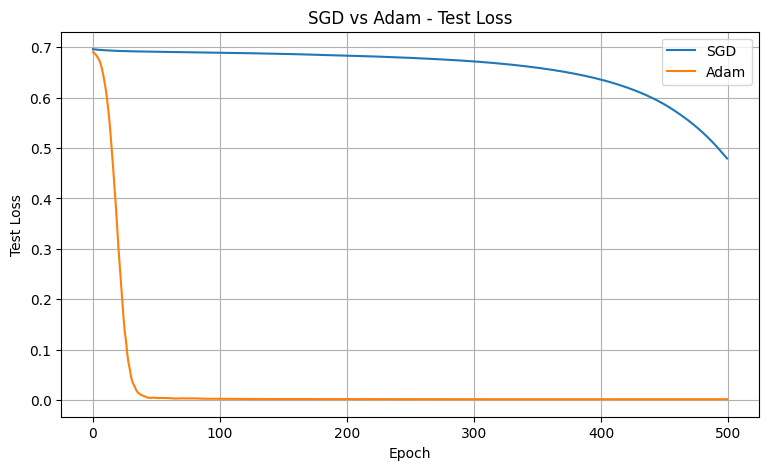

In [38]:
plt.figure(figsize=(9, 5))

plt.plot(
    sgd_results["test_loss"],
    label="SGD"
)

plt.plot(
    adam_results["test_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("SGD vs Adam - Test Loss")

plt.legend()
plt.grid()

plt.show()

#### Discussion

The Adam and SGD experiments demonstrate a clear difference in convergence
speed and final performance. Both optimizers were applied to the same V2
architecture, using the same dataset, loss function, and number of training
epochs. Therefore, the observed difference can primarily be attributed to the
optimization method and the selected learning rates.

SGD showed gradual improvement throughout training. Its test accuracy increased
from 80.5% at the beginning of training to 99.0% by epoch 400. However, it did
not reach the same final performance as Adam within the 500 available epochs.
Its final test loss was approximately 0.4792.

In contrast, Adam converged much more rapidly. It started with a test accuracy
of 54.0% and reached 100.0% test accuracy by approximately epoch 100. It
maintained this accuracy for the remaining training epochs, while its test loss
continued to decrease to approximately 0.0021.

The difference can also be observed in the test-loss curve. The Adam curve
decreases much more rapidly than the SGD curve, indicating that Adam was able
to optimize the model parameters more efficiently for this problem. SGD shows
a slower reduction in loss and requires considerably more epochs to approach
high classification accuracy.

The final results show that Adam achieved 100.0% test accuracy compared with
99.0% for SGD. More importantly, Adam achieved this performance much earlier
during training. Therefore, for this particular dataset and Model V2
architecture, Adam provided faster convergence and a lower final test loss
than SGD.

It should be noted that the comparison uses different learning rates for the
two optimizers (0.09 for SGD and 0.01 for Adam), as specified in the experiment.
Therefore, the results demonstrate the performance of these particular
optimizer and learning-rate configurations rather than proving that Adam is
always superior to SGD under every possible configuration.

Overall, the experiment indicates that Adam was the more effective optimizer
for this circular classification task under the selected experimental settings.

## Submission
- Upload the `PDF` for the .ipynb file (might need to convert it) to the assignment portal by the deadline. Additionally, providing the exact url to the Github file in your repo is recommended.